In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/student_performance.csv")
df.head()# Printing first 5 rows of dataset

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final
0,1,Ali,M,16,5,90,9,75,72,80
1,2,Ahmed,M,15,3,70,6,55,60,58
2,3,Sara,F,16,7,95,10,88,85,92
3,4,Fatima,F,15,6,92,9,82,80,87
4,5,Usman,M,16,2,65,5,48,52,50


In [3]:
#Adding new features like columns Average_Score and Improvement
# Average score of mid term and final
df["Average_Score"] = (
    df["Midterm"] + df["Final"]
) / 2
df.head()

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score
0,1,Ali,M,16,5,90,9,75,72,80,77.5
1,2,Ahmed,M,15,3,70,6,55,60,58,56.5
2,3,Sara,F,16,7,95,10,88,85,92,90.0
3,4,Fatima,F,15,6,92,9,82,80,87,84.5
4,5,Usman,M,16,2,65,5,48,52,50,49.0


In [4]:
df["Improvement"] = df["Final"] - df["Previous_Score"]
df.head(3)

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement
0,1,Ali,M,16,5,90,9,75,72,80,77.5,8
1,2,Ahmed,M,15,3,70,6,55,60,58,56.5,-2
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7


In [5]:
def grade_category(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Very Good"
    elif score >= 70:
        return "Good"
    elif score >= 60:
        return "Average"
    elif score >= 50:
        return "Needs Improvement"
    else:
        return "At Risk"

In [6]:
df["Category"] = df["Final"].apply(
    grade_category
)

In [7]:
df[["Name", "Final", "Category"]]

,Name,Final,Category
0,Ali,80,Very Good
1,Ahmed,58,Needs Improvement
2,Sara,92,Excellent
3,Fatima,87,Very Good
4,Usman,50,Needs Improvement
5,Ayesha,95,Excellent
6,Bilal,72,Good
7,Zain,65,Average
8,Maryam,98,Excellent
9,Hassan,42,At Risk


In [8]:
print(f"Average final score:{df["Final"].mean():.2f}")

Average final score:76.88


In [9]:
# Who scored highest marks
print(f"The student who scored highest marks\n{df.loc[df['Final'].idxmax()]}")

The student who scored highest marks
Student_ID                9
Name                 Maryam
Gender                    F
Age                      16
Study_Hours               9
Attendance               99
Assignments              10
Midterm                  95
Previous_Score           94
Final                    98
Average_Score          96.5
Improvement               4
Category          Excellent
Name: 8, dtype: object


In [10]:
# Printing only name and marks
top_student_name = df.loc[df["Final"].idxmax()]["Name"]
top_student_marks = df.loc[df["Final"].idxmax()]["Final"]
print(f"The student Name who scored highest marks:{top_student_name}")
print(f"And marks are:{top_student_marks}")

The student Name who scored highest marks:Maryam
And marks are:98


In [11]:
# Handle Ties (Multiple Highest Scorers)idxmax() only returns the first highest index it 
#finds. If two students both scored 100, it misses the second student.
# To find all students with the highest score, use boolean indexing instead:
# 1. Find the maximum value in the Final column
max_scores = df['Final'].max()
# 2. Filter the DataFrame for all rows matching that maximum value
top_scores_df = df[df['Final'] == max_scores]
# Extract just names as a list
top_names = top_scores_df['Name'].tolist()
print(f"The student(s) who scores highest marks= {max_scores} : {', '.join(top_names)}")

The student(s) who scores highest marks= 98 : Maryam, Mubashar


In [12]:
# Who scored lowest marks
print(f"The student who scored lowest marks:\n{df.loc[df['Final'].idxmin()]}")

The student who scored lowest marks:
Student_ID             10
Name               Hassan
Gender                  M
Age                    15
Study_Hours             1
Attendance             55
Assignments             4
Midterm                40
Previous_Score         45
Final                  42
Average_Score        41.0
Improvement            -3
Category          At Risk
Name: 9, dtype: object


In [13]:
# Handle Ties (Multiple Highest Scorers)idxmax() only returns the first highest index 
# it finds. If two students both scored 100, it misses the second student.
# To find all students with the lowest score, use boolean indexing instead:
# 1. Find the min value in the Final column
min_scores = df['Final'].min()
# 2. Filter the DataFrame for all rows matching that maximum value
min_scores_df = df[df['Final'] == min_scores]
# Extract just names as a list
min_names = min_scores_df['Name'].tolist()
print(f"The student(s) who scores lowest marks= {min_scores} : {', '.join(min_names)}")

The student(s) who scores lowest marks= 42 : Hassan


In [14]:
# Finds the top 3 rows based on the 'Final' column
top_three_df = df.nlargest(3, 'Final')
print(top_three_df)


    Student_ID      Name Gender  Age  Study_Hours  Attendance  Assignments  \
8            9    Maryam      F   16            9          99           10   
15          16  Mubashar      M   20            7          80           10   
5            6    Ayesha      F   15            8          98           10   

    Midterm  Previous_Score  Final  Average_Score  Improvement   Category  
8        95              94     98           96.5            4  Excellent  
15       70              85     98           84.0           13  Excellent  
5        92              90     95           93.5            5  Excellent  


In [18]:
# Print only names and marks of top three students
top_three_names = df.nlargest(3, 'Final')['Name'].tolist()
print(f"The top three students are: {', '.join(top_three_names)}")

The top three students are: Maryam, Mubashar, Ayesha


In [16]:
# Print as a Clean List (Using a Loop)This method iterates through the top three rows 
# and prints each student's name and score on a new line.
# Get the top three row
top_three = df.nlargest(3, 'Final')
# Loop through and get the names and marks of top three students
print("Top three students")
for index, row in top_three.iterrows():
    print(f"-{row['Name']}: {row['Final']}")

Top three students
-Maryam: 98
-Mubashar: 98
-Ayesha: 95


In [17]:
# If you want to keep the tabular structure but hide irrelevant columns (like ID or age), 
# you can filter the DataFrame directly.
top_three_summary = df.nlargest(3, 'Final')[['Name', 'Final']]
# index=False hides the row numbers
print(top_three_summary.to_string(index=False))

    Name  Final
  Maryam     98
Mubashar     98
  Ayesha     95


In [18]:
# The students with attendance more than 90%
df[df["Attendance"] > 90]

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7,Excellent
3,4,Fatima,F,15,6,92,9,82,80,87,84.5,7,Very Good
5,6,Ayesha,F,15,8,98,10,92,90,95,93.5,5,Excellent
8,9,Maryam,F,16,9,99,10,95,94,98,96.5,4,Excellent
12,13,Noor,F,16,7,93,9,86,84,89,87.5,5,Very Good
14,15,Eman,F,16,8,97,10,90,91,94,92.0,3,Excellent


In [19]:
# Students studying more than 6 hours
df[df["Study_Hours"] > 6]

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7,Excellent
5,6,Ayesha,F,15,8,98,10,92,90,95,93.5,5,Excellent
8,9,Maryam,F,16,9,99,10,95,94,98,96.5,4,Excellent
12,13,Noor,F,16,7,93,9,86,84,89,87.5,5,Very Good
14,15,Eman,F,16,8,97,10,90,91,94,92.0,3,Excellent
15,16,Mubashar,M,20,7,80,10,70,85,98,84.0,13,Excellent


In [20]:
# Students scoring above 80
df[df["Final"] > 80]

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7,Excellent
3,4,Fatima,F,15,6,92,9,82,80,87,84.5,7,Very Good
5,6,Ayesha,F,15,8,98,10,92,90,95,93.5,5,Excellent
8,9,Maryam,F,16,9,99,10,95,94,98,96.5,4,Excellent
10,11,Hina,F,16,6,88,8,78,75,82,80.0,7,Very Good
12,13,Noor,F,16,7,93,9,86,84,89,87.5,5,Very Good
14,15,Eman,F,16,8,97,10,90,91,94,92.0,3,Excellent
15,16,Mubashar,M,20,7,80,10,70,85,98,84.0,13,Excellent


In [21]:
# Top students
df.sort_values(
    by="Final",
    ascending=False
)

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
8,9,Maryam,F,16,9,99,10,95,94,98,96.5,4,Excellent
15,16,Mubashar,M,20,7,80,10,70,85,98,84.0,13,Excellent
5,6,Ayesha,F,15,8,98,10,92,90,95,93.5,5,Excellent
14,15,Eman,F,16,8,97,10,90,91,94,92.0,3,Excellent
2,3,Sara,F,16,7,95,10,88,85,92,90.0,7,Excellent
12,13,Noor,F,16,7,93,9,86,84,89,87.5,5,Very Good
3,4,Fatima,F,15,6,92,9,82,80,87,84.5,7,Very Good
10,11,Hina,F,16,6,88,8,78,75,82,80.0,7,Very Good
0,1,Ali,M,16,5,90,9,75,72,80,77.5,8,Very Good
11,12,Hamza,M,15,5,85,8,72,70,76,74.0,6,Good


In [22]:
# Bottom Students
df.sort_values(
    by="Final"
)

,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement,Category
9,10,Hassan,M,15,1,55,4,40,45,42,41.0,-3,At Risk
4,5,Usman,M,16,2,65,5,48,52,50,49.0,-2,Needs Improvement
13,14,Daniyal,M,15,2,60,5,50,48,52,51.0,4,Needs Improvement
1,2,Ahmed,M,15,3,70,6,55,60,58,56.5,-2,Needs Improvement
7,8,Zain,M,15,3,75,6,58,62,65,61.5,3,Average
6,7,Bilal,M,16,4,80,7,65,68,72,68.5,4,Good
11,12,Hamza,M,15,5,85,8,72,70,76,74.0,6,Good
0,1,Ali,M,16,5,90,9,75,72,80,77.5,8,Very Good
10,11,Hina,F,16,6,88,8,78,75,82,80.0,7,Very Good
3,4,Fatima,F,15,6,92,9,82,80,87,84.5,7,Very Good


In [23]:
# Group Analysis 
# Average marks by gender
df.groupby("Gender")["Final"].mean().map('{:.2f}%'.format)

Gender
F    91.00%
M    65.89%
Name: Final, dtype: object

In [24]:
# Group Analysis 
# Average attendance by gender
df.groupby("Gender")["Attendance"].mean().map('{:.2f}%'.format)

Gender
F    94.57%
M    73.33%
Name: Attendance, dtype: object

In [25]:
# Count students by category
df["Category"].value_counts()

Category
Excellent            5
Very Good            4
Needs Improvement    3
Good                 2
Average              1
At Risk              1
Name: count, dtype: int64

In [26]:
#Correlation Analysis
#Relationship between numerical columns:
df.select_dtypes(
   include="number" 
).corr()

,Student_ID,Age,Study_Hours,Attendance,Assignments,Midterm,Previous_Score,Final,Average_Score,Improvement
Student_ID,1.000000,0.383547,0.162529,-0.067718,0.060194,0.023529,0.107611,0.142660,0.086361,0.230860
Age,0.383547,1.000000,0.345476,0.127442,0.406804,0.143704,0.356976,0.436072,0.299191,0.598283
Study_Hours,0.162529,0.345476,1.000000,0.934794,0.964506,0.966698,0.990985,0.976045,0.986078,0.603879
Attendance,-0.067718,0.127442,0.934794,1.000000,0.935832,0.984564,0.945629,0.928359,0.969832,0.562655
Assignments,0.060194,0.406804,0.964506,0.935832,1.000000,0.942793,0.972992,0.986605,0.979890,0.720386
Midterm,0.023529,0.143704,0.966698,0.984564,0.942793,1.000000,0.961872,0.941351,0.984217,0.559006
Previous_Score,0.107611,0.356976,0.990985,0.945629,0.972992,0.961872,1.000000,0.984322,0.988051,0.606660
Final,0.142660,0.436072,0.976045,0.928359,0.986605,0.941351,0.984322,1.000000,0.986207,0.737363
Average_Score,0.086361,0.299191,0.986078,0.969832,0.979890,0.984217,0.988051,0.986207,1.000000,0.660919
Improvement,0.230860,0.598283,0.603879,0.562655,0.720386,0.559006,0.606660,0.737363,0.660919,1.000000


In [27]:
df.to_csv(
    "../data/student_performance_cleaned.csv",
    index=False
)

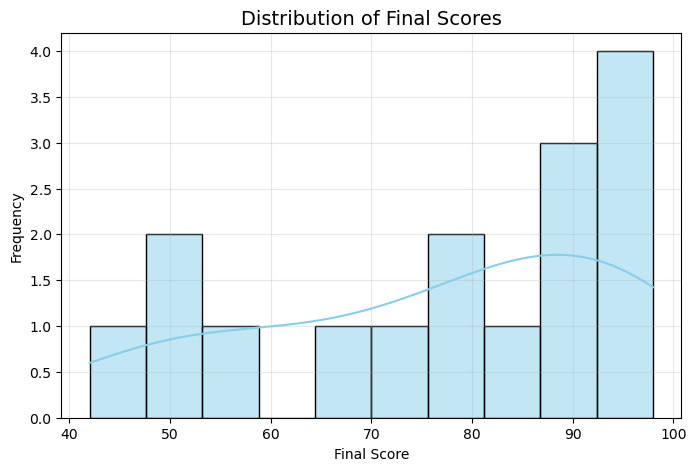

In [28]:
#1. Distribution of Final Scores (Histogram + KDE)
plt.figure(figsize=(8,5))
sns.histplot(df['Final'], kde=True, bins=10, color='skyblue')
plt.title('Distribution of Final Scores', fontsize=14)
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()
# Insight: Visualises the spread and central tendency of final grades. 
# Helps identify if scores are skewed or roughly normal.

C:\Users\ADEEL COMPUTERS\AppData\Local\Temp\ipykernel_10468\10389986.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Gender', y='Final', data=df, estimator='mean', ci=None, palette='pastel')
C:\Users\ADEEL COMPUTERS\AppData\Local\Temp\ipykernel_10468\10389986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Final', data=df, estimator='mean', ci=None, palette='pastel')


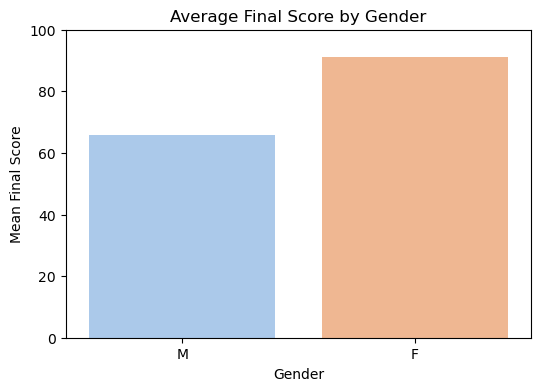

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Final', data=df, estimator='mean', ci=None, palette='pastel')
plt.title('Average Final Score by Gender')
plt.ylabel('Mean Final Score')
plt.ylim(0, 100)
plt.show()

C:\Users\ADEEL COMPUTERS\AppData\Local\Temp\ipykernel_10468\1681534152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Attendance', data=df,


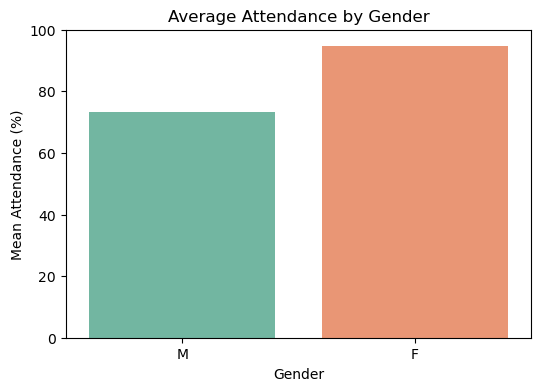

In [30]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Attendance', data=df, 
            estimator='mean', errorbar=None, palette='Set2')
plt.title('Average Attendance by Gender')
plt.ylabel('Mean Attendance (%)')
plt.ylim(0, 100)
plt.show()

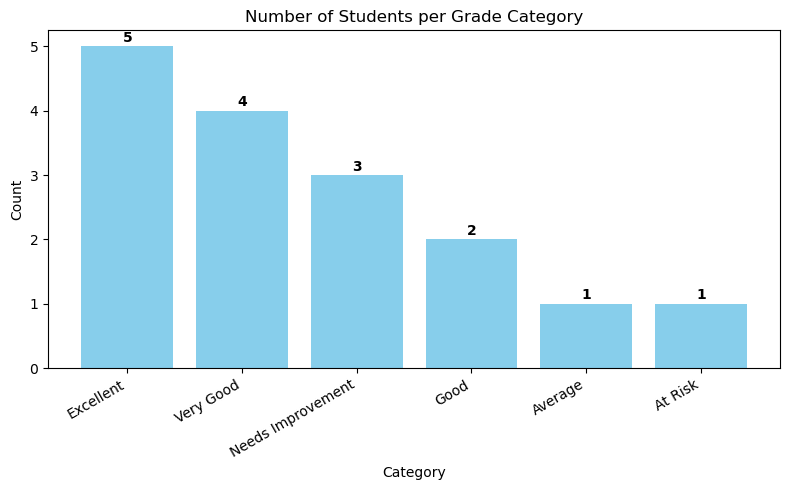

In [34]:
# 1. COUNT STUDENTS BY CATEGORY
# .value_counts() counts how many students fall into each grade category.
# This returns a Series with the category names as the index and counts as values.
category_counts = df["Category"].value_counts()

# 2. CREATE THE PLOT
# Using plt.subplots() gives us access to the Axes object ('ax') for easier labeling.
fig, ax = plt.subplots(figsize=(8,5))

# Draw the bar chart. Store the returned BarContainer in 'bars' so we can label them.
bars = ax.bar(category_counts.index, category_counts.values, color='skyblue')

# 3. ADD THE COUNT NUMBERS ON TOP OF THE BARS (THE MAGIC LINE)
# bar_label() automatically places the value of each bar at its top edge.
# padding=3 adds a small gap between the bar top and the number.
# fontweight='bold' makes the numbers stand out.
ax.bar_label(bars, padding=1, fontweight='bold')

# 4. FORMATTING & LABELS
ax.set_title("Number of Students per Grade Category")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
# Rotate the X-axis labels so they don't overlap.
plt.xticks(rotation=30, ha='right')

# 5. DISPLAY THE CHART
plt.tight_layout()  # Adjusts spacing to prevent clipping
plt.show()